In [243]:
import pandas as pd
import numpy as np
import seaborn as sns 

In [244]:
df=pd.read_excel('Company stock prices.xlsx')

In [245]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-10-19,537.070007,541.799988,525.380005,530.719971,530.719971,7567500
1,2020-10-20,528.140015,533.780029,522.260010,525.419983,525.419983,10047200
2,2020-10-21,501.029999,506.850006,488.250000,489.049988,489.049988,17405700
3,2020-10-22,494.690002,495.140015,482.000000,485.230011,485.230011,6997900
4,2020-10-23,488.109985,490.059998,481.350006,488.279999,488.279999,4927900


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       753 non-null    datetime64[ns]
 1   Open       753 non-null    float64       
 2   High       753 non-null    float64       
 3   Low        753 non-null    float64       
 4   Close      753 non-null    float64       
 5   Adj Close  753 non-null    float64       
 6   Volume     753 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 41.3 KB


In [247]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [248]:
df.shape

(753, 7)

In [249]:
df.duplicated().sum()

np.int64(0)

In [250]:
are_identical = df['Close'].equals(df['Adj Close'])
print(f"Are they identical? {are_identical}")
#iam thinking to drop this close col

Are they identical? True


In [251]:
df=df.set_index('Date').sort_index()
#here iam converting this index to this date and as well as sorting this index 
#cuz in this time series the order and spacing of the data points are what matter most

<Axes: ylabel='Open'>

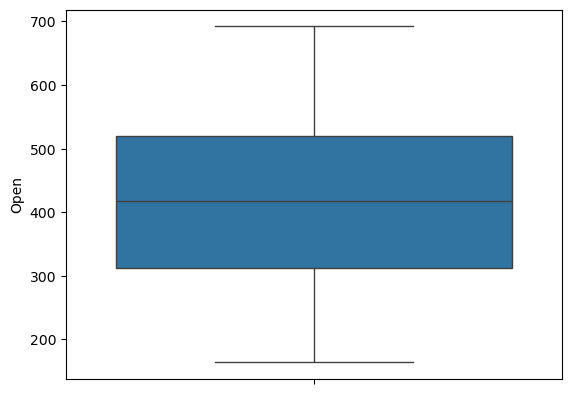

In [252]:
sns.boxplot(df['Open'])

<Axes: ylabel='Volume'>

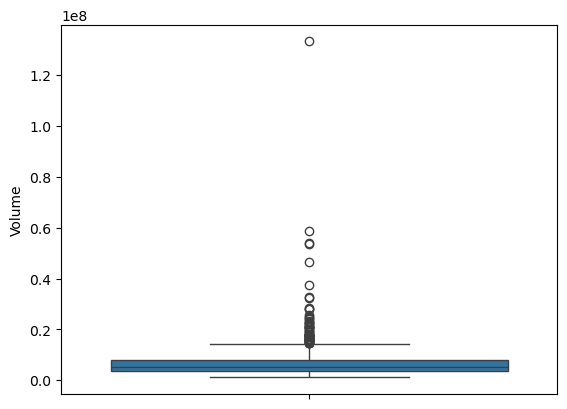

In [253]:
sns.boxplot(df['Volume'])

In [254]:
df['Log_Volume'] = np.log(df['Volume'])

<Axes: ylabel='Log_Volume'>

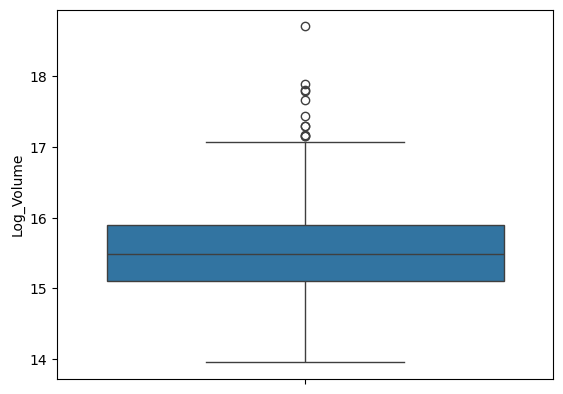

In [255]:
sns.boxplot(df['Log_Volume'])

<Axes: ylabel='High'>

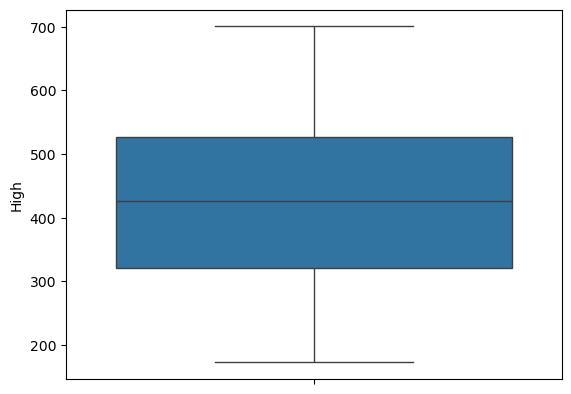

In [256]:
sns.boxplot(df['High'])

<Axes: ylabel='Low'>

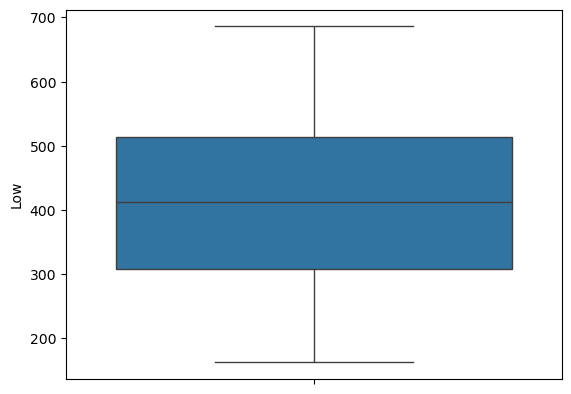

In [257]:
sns.boxplot(df['Low'])

<Axes: ylabel='Close'>

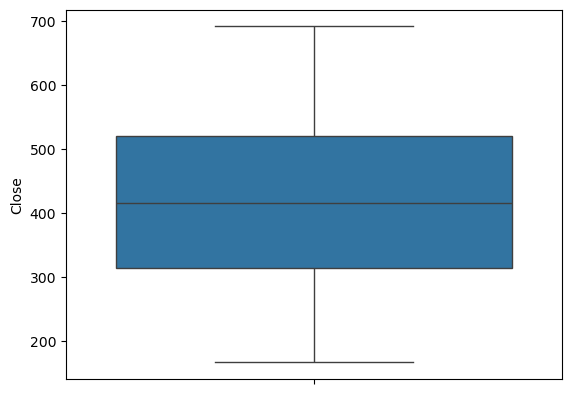

In [258]:
sns.boxplot(df['Close'])

<Axes: ylabel='Adj Close'>

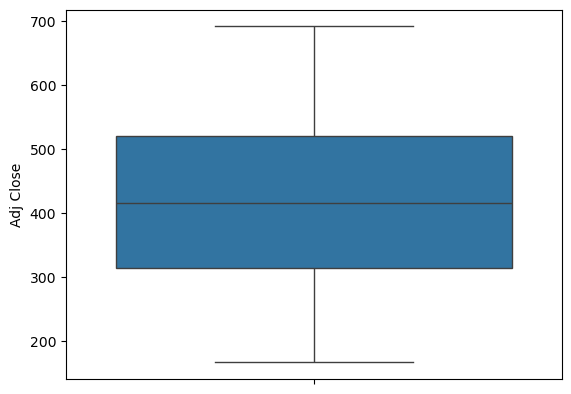

In [259]:
sns.boxplot(df['Adj Close'])

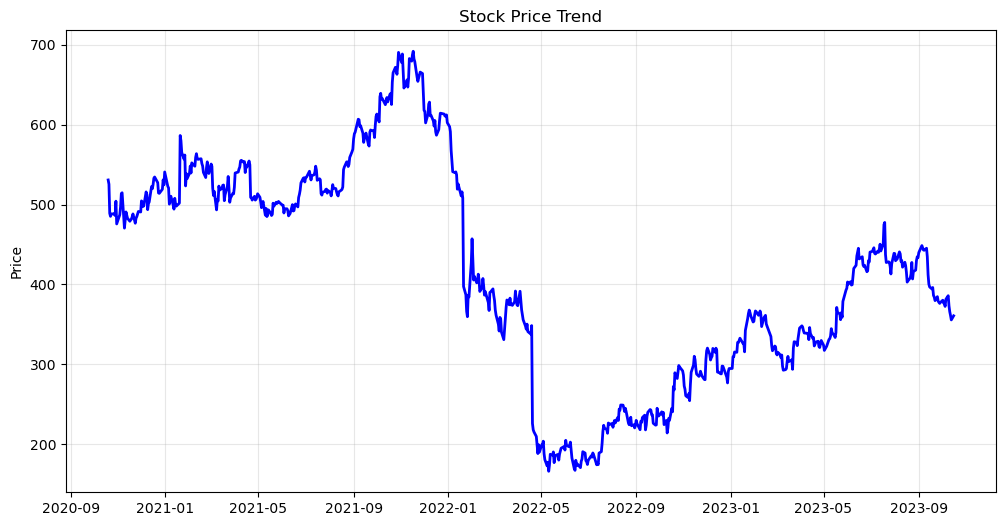

In [260]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
plt.plot(df['Adj Close'], color="blue", linewidth=2)
plt.title('Stock Price Trend')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.show()


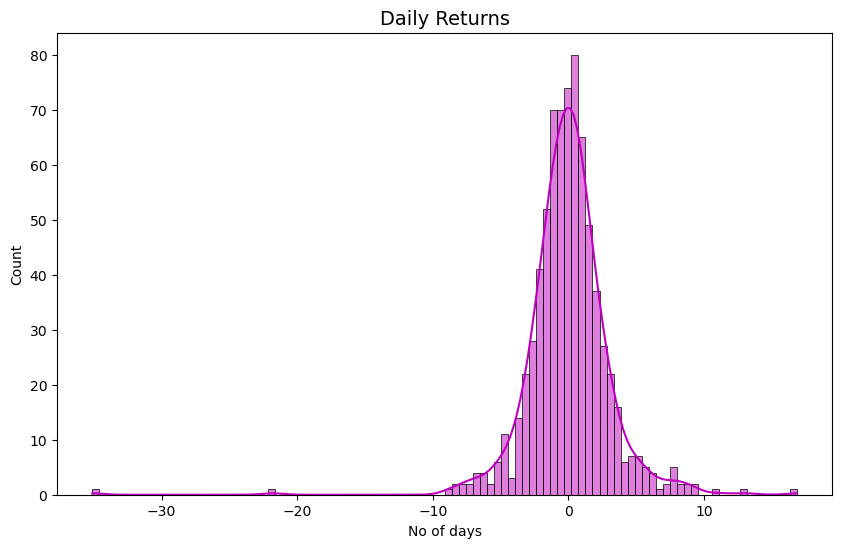

In [261]:
# Calculate returns first if you haven't yet
df['Daily_Return'] = df['Adj Close'].pct_change()
df['Return_Percentage'] = df['Daily_Return'] * 100


plt.figure(figsize=(10, 6))
sns.histplot(df['Return_Percentage'].dropna(), bins=100, kde=True, color='m')
plt.title('Daily Returns', fontsize=14)
plt.xlabel('No of days')
plt.show()


In [262]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,Log_Volume,Daily_Return,Return_Percentage
Date,,,,,,,,,
2020-10-19,537.070007,541.799988,525.380005,530.719971,530.719971,7567500,15.839373,NaN,NaN
2020-10-20,528.140015,533.780029,522.260010,525.419983,525.419983,10047200,16.122805,-0.009986,-0.998641
2020-10-21,501.029999,506.850006,488.250000,489.049988,489.049988,17405700,16.672308,-0.069221,-6.922081
2020-10-22,494.690002,495.140015,482.000000,485.230011,485.230011,6997900,15.761121,-0.007811,-0.781102
2020-10-23,488.109985,490.059998,481.350006,488.279999,488.279999,4927900,15.410423,0.006286,0.628565


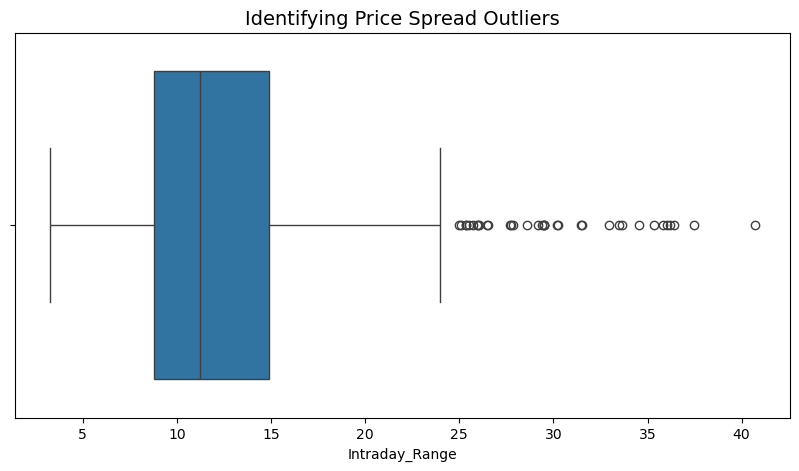

In [263]:
df['Intraday_Range'] = df['High'] - df['Low']

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Intraday_Range'])
plt.title('Identifying Price Spread Outliers', fontsize=14)
plt.show()


In [264]:
df['Log_Intraday_Range'] = np.log(df['Intraday_Range'])

<Axes: xlabel='Intraday_Range', ylabel='Count'>

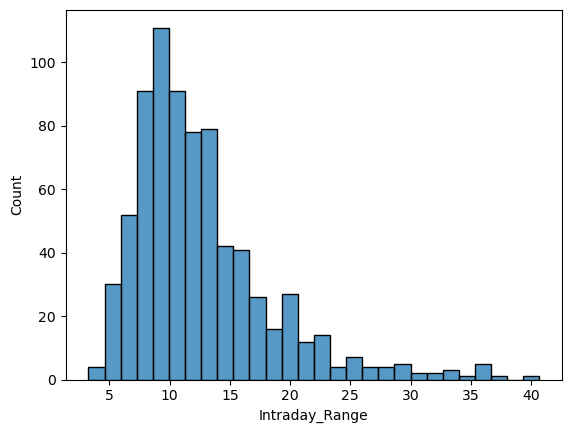

In [265]:
sns.histplot(x='Intraday_Range',data=df)

<Axes: xlabel='Log_Intraday_Range', ylabel='Count'>

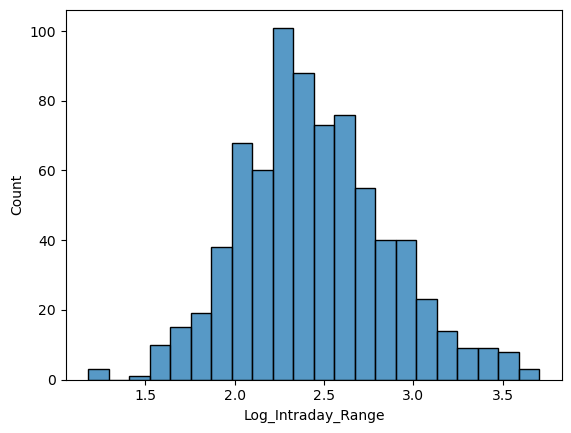

In [266]:
sns.histplot(x='Log_Intraday_Range',data=df)

In [267]:
df.sample(5)

,Open,High,Low,Close,Adj Close,Volume,Log_Volume,Daily_Return,Return_Percentage,Intraday_Range,Log_Intraday_Range
Date,,,,,,,,,,,
2021-06-11,490.000000,491.410004,487.779999,488.769989,488.769989,3124000,14.954625,0.003078,0.307838,3.630005,1.289234
2020-11-25,485.130005,486.899994,478.920013,485.000000,485.000000,3598600,15.096055,0.004390,0.439031,7.979981,2.076936
2020-11-02,478.869995,486.299988,475.000000,484.119995,484.119995,4408200,15.298977,0.017615,1.761467,11.299988,2.424802
2023-06-21,432.649994,434.549988,422.540009,424.450012,424.450012,5146400,15.453808,-0.023579,-2.357948,12.009979,2.485738
2022-12-20,281.239990,289.279999,280.809998,288.190002,288.190002,6918100,15.749652,-0.000381,-0.038150,8.470001,2.136531


In [268]:
#Measures how far the stock fell from its high before closing
df['Upper_Shadow'] = df['High'] - df['Adj Close']
df['Upper_Shadow_Pct'] = (df['High'] - df['Adj Close']) / df['Adj Close'] * 100



In [269]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Log_Volume',
       'Daily_Return', 'Return_Percentage', 'Intraday_Range',
       'Log_Intraday_Range', 'Upper_Shadow', 'Upper_Shadow_Pct'],
      dtype='object')

In [270]:
df.corr()

,Open,High,Low,Close,Adj Close,Volume,Log_Volume,Daily_Return,Return_Percentage,Intraday_Range,Log_Intraday_Range,Upper_Shadow,Upper_Shadow_Pct
Open,1.000000,0.999187,0.999223,0.998184,0.998184,-0.391318,-0.631157,-0.015273,-0.015273,0.268184,0.285881,0.191416,-0.230579
High,0.999187,1.000000,0.999152,0.999224,0.999224,-0.383515,-0.619591,0.007385,0.007385,0.288943,0.305840,0.185871,-0.236533
Low,0.999223,0.999152,1.000000,0.999233,0.999233,-0.400809,-0.639166,0.008241,0.008241,0.249284,0.268189,0.164345,-0.254978
Close,0.998184,0.999224,0.999233,1.000000,1.000000,-0.390191,-0.627664,0.029170,0.029170,0.268802,0.286488,0.147029,-0.271834
Adj Close,0.998184,0.999224,0.999233,1.000000,1.000000,-0.390191,-0.627664,0.029170,0.029170,0.268802,0.286488,0.147029,-0.271834
Volume,-0.391318,-0.383515,-0.400809,-0.390191,-0.390191,1.000000,0.793015,-0.196111,-0.196111,0.298882,0.262847,0.102696,0.314260
Log_Volume,-0.631157,-0.619591,-0.639166,-0.627664,-0.627664,0.793015,1.000000,0.004347,0.004347,0.288366,0.276592,0.098223,0.350721
Daily_Return,-0.015273,0.007385,0.008241,0.029170,0.029170,-0.196111,0.004347,1.000000,1.000000,-0.017923,0.003166,-0.542313,-0.610370
Return_Percentage,-0.015273,0.007385,0.008241,0.029170,0.029170,-0.196111,0.004347,1.000000,1.000000,-0.017923,0.003166,-0.542313,-0.610370
Intraday_Range,0.268184,0.288943,0.249284,0.268802,0.268802,0.298882,0.288366,-0.017923,-0.017923,1.000000,0.957842,0.550598,0.365212


In [ ]:
#From the correlation alaysis we are going with this final features
Final_Features=['Adj Close','Log_Volume','Return_Percentage','Log_Intraday_Range','Upper_Shadow_Pct']